<a href="https://colab.research.google.com/github/akshita2736/autism_detection/blob/main/autism_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [261]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [263]:
df = pd.read_csv('autism dataset.csv')

In [264]:
df.head()                 # ID and age_desc remove -- not relevant

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26.0,f,White-European,no,no,United States,no,6,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,24.0,m,Latino,no,yes,Brazil,no,5,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,27.0,m,Latino,yes,yes,Spain,no,8,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,35.0,f,White-European,no,yes,United States,no,6,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,40.0,f,?,no,no,Egypt,no,2,18 and more,?,NO


In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    object 
 12  ethnicity        704 non-null    object 
 13  jaundice         704 non-null    object 
 14  autism           704 non-null    object 
 15  contry_of_res    704 non-null    object 
 16  used_app_before  704 non-null    object 
 17  result          

In [266]:
df.shape

(704, 21)

In [267]:
df.tail()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
699,0,1,0,1,1,0,1,1,1,1,25.0,f,White-European,no,no,Russia,no,7,18 and more,Self,YES
700,1,0,0,0,0,0,0,1,0,1,34.0,m,Hispanic,no,no,Mexico,no,3,18 and more,Parent,NO
701,1,0,1,1,1,0,1,1,0,1,24.0,f,?,no,no,Russia,no,7,18 and more,?,YES
702,1,0,0,1,1,0,1,0,1,1,35.0,m,South Asian,no,no,Pakistan,no,6,18 and more,Self,NO
703,1,0,1,1,1,0,1,1,1,1,26.0,f,White-European,no,no,Cyprus,no,8,18 and more,Self,YES


In [268]:
pd.set_option('display.max_columns', None)
# to display all columns everytime

In [269]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26.0,f,White-European,no,no,United States,no,6,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,24.0,m,Latino,no,yes,Brazil,no,5,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,27.0,m,Latino,yes,yes,Spain,no,8,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,35.0,f,White-European,no,yes,United States,no,6,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,40.0,f,?,no,no,Egypt,no,2,18 and more,?,NO


In [270]:
print(df['age'].isnull().sum())

2


In [271]:
# age (float to int)
df['age'] = df['age'].fillna(df['age'].median())
df['age'] = df['age'].astype(int)
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26,f,White-European,no,no,United States,no,6,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,24,m,Latino,no,yes,Brazil,no,5,18 and more,Self,NO


In [272]:
# check all unique values in the categorical columns (avoid overfitting)
for col in df.columns:
  numerical_features = ['ID', 'age', 'result']
  if col not in numerical_features:
    print(col,df[col].unique())
    print("-"*50)

A1_Score [1 0]
--------------------------------------------------
A2_Score [1 0]
--------------------------------------------------
A3_Score [1 0]
--------------------------------------------------
A4_Score [1 0]
--------------------------------------------------
A5_Score [0 1]
--------------------------------------------------
A6_Score [0 1]
--------------------------------------------------
A7_Score [1 0]
--------------------------------------------------
A8_Score [1 0]
--------------------------------------------------
A9_Score [0 1]
--------------------------------------------------
A10_Score [0 1]
--------------------------------------------------
gender ['f' 'm']
--------------------------------------------------
ethnicity ['White-European' 'Latino' '?' 'Others' 'Black' 'Asian' 'Middle Eastern '
 'Pasifika' 'South Asian' 'Hispanic' 'Turkish' 'others']
--------------------------------------------------
jaundice ['no' 'yes']
--------------------------------------------------
autism

In [273]:
# remove irrelevant columns
df = df.drop(columns=['ID', 'age_desc'], errors='ignore')
df.shape

(704, 20)

In [274]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26,f,White-European,no,no,United States,no,6,Self,NO
1,1,1,0,1,0,0,0,1,0,1,24,m,Latino,no,yes,Brazil,no,5,Self,NO


In [275]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'autism', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

In [276]:
df['contry_of_res'].unique()

array(['United States', 'Brazil', 'Spain', 'Egypt', 'New Zealand',
       'Bahamas', 'Burundi', 'Austria', 'Argentina', 'Jordan', 'Ireland',
       'United Arab Emirates', 'Afghanistan', 'Lebanon', 'United Kingdom',
       'South Africa', 'Italy', 'Pakistan', 'Bangladesh', 'Chile',
       'France', 'China', 'Australia', 'Canada', 'Saudi Arabia',
       'Netherlands', 'Romania', 'Sweden', 'Tonga', 'Oman', 'India',
       'Philippines', 'Sri Lanka', 'Sierra Leone', 'Ethiopia', 'Viet Nam',
       'Iran', 'Costa Rica', 'Germany', 'Mexico', 'Russia', 'Armenia',
       'Iceland', 'Nicaragua', 'Hong Kong', 'Japan', 'Ukraine',
       'Kazakhstan', 'AmericanSamoa', 'Uruguay', 'Serbia', 'Portugal',
       'Malaysia', 'Ecuador', 'Niger', 'Belgium', 'Bolivia', 'Aruba',
       'Finland', 'Turkey', 'Nepal', 'Indonesia', 'Angola', 'Azerbaijan',
       'Iraq', 'Czech Republic', 'Cyprus'], dtype=object)

In [277]:
num_categories = df['contry_of_res'].nunique()
print("no. of unique countries: ", num_categories)

no. of unique countries:  67


In [278]:
# mapping together similar countries to reduce no. of country attributes
mapping = {
    "Viet nam": "Vietnam",
    "AmericanSamoa": "United States",
    "Hong Kong": "China"
}

df['contry_of_res'] = df['contry_of_res'].replace(mapping)

In [279]:
num_categories = df['contry_of_res'].nunique()
print("no. of unique countries: ", num_categories)

no. of unique countries:  65


In [280]:
df['Class/ASD'].value_counts()
# huge class imbalance -- might lead to bias in ML model

,count
Class/ASD,
NO,515
YES,189


EDA

In [281]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'autism', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD'],
      dtype='object')

Numerical columns (age and result) -- univariate analysis

Mean age: 29.69034090909091
Median age: 27.0


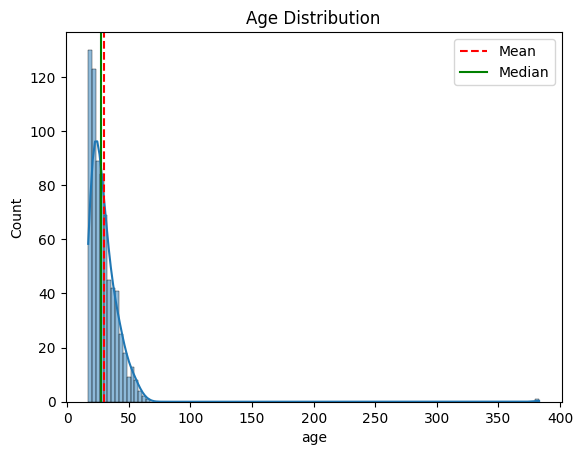

In [282]:
# AGE COLUMN:

sns.histplot(df ["age"], kde=True)
plt.title("Age Distribution")
# Calculate mean and median of age
mean_age = df ["age"]. mean ( )
median_age = df ["age"]. median ( )
# Print values
print ("Mean age:", mean_age)
print ("Median age:", median_age)
# Draw vertical lines for mean and median on the plot
plt.axvline(mean_age, color="red", linestyle="--", label="Mean")
plt. axvline (median_age, color="green", linestyle="-", label="Median")

plt.legend()
plt.show()

Mean result: 4.875
Median result: 4.0


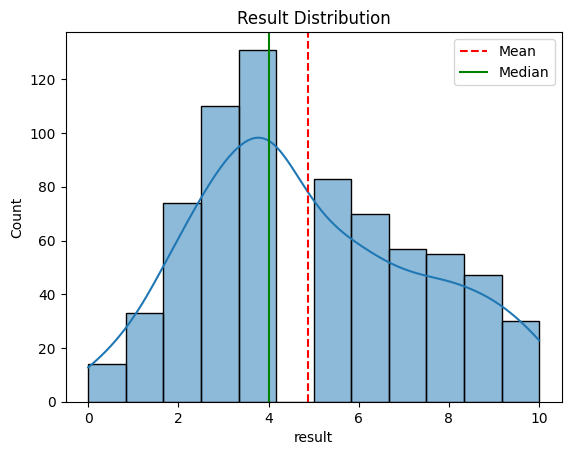

In [283]:
# RESULT COLUMN

sns.histplot(df ["result"], kde=True)
plt.title("Result Distribution")
# Calculate mean and median of result
mean_result = df ["result"]. mean ( )
median_result = df ["result"]. median ( )
# Print values
print ("Mean result:", mean_result)
print ("Median result:", median_result)

# Draw vertical lines for mean and median on the plot
plt.axvline(mean_result, color="red", linestyle="--", label="Mean")
plt.axvline(median_result, color="green", linestyle="-", label="Median" )

plt.legend()
plt.show()

finding outliers using boxplot and IQR method

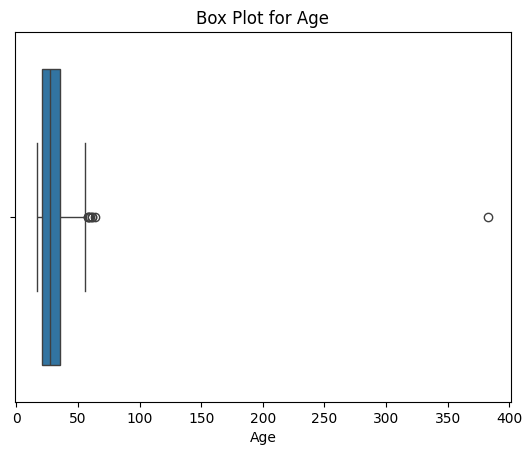

In [284]:
sns.boxplot(x=df["age"])
plt.title ("Box Plot for Age")
plt.xlabel ("Age")
plt.show()

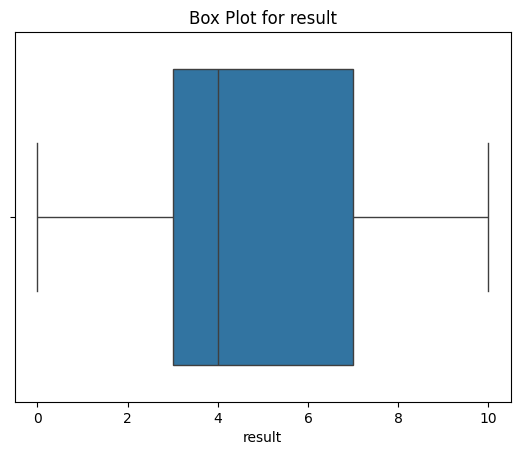

In [285]:
sns.boxplot(x=df["result"])
plt.title ("Box Plot for result")
plt.xlabel ("result")
plt.show()

count outliers using IQR method

In [286]:
# AGE COLUMN

Q1 = df["age"].quantile(0.25)
Q3 = df["age"]. quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
age_outliers = df[(df["age"] < lower_bound) | (df["age"] > upper_bound)]

In [287]:
len(age_outliers)         # 39 samples are outliers -- replace with median

8

In [288]:
median_age = df['age'].median()

# df.loc -- access rows in df by condition
df. loc[df["age"] < lower_bound, "age"] = median_age
df. loc[df["age"] > upper_bound, "age"] = median_age
print("Outliers in age column have been replaced with the median.")

Outliers in age column have been replaced with the median.


In [289]:
# RESULT COLUMN

Q1 = df["result"].quantile(0.25)
Q3 = df["result"]. quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
result_outliers = df[(df["result"] < lower_bound) | (df["result"] > upper_bound)]

len(result_outliers)

0

In [290]:
median_result = df['result'].median()

# df.loc -- access rows in df by condition
df. loc[df["result"] < lower_bound, "result"] = median_result
df. loc[df["result"] > upper_bound, "result"] = median_result
print("Outliers in result column have been replaced with the median.")

Outliers in result column have been replaced with the median.


Univariate analysis of Categorical columns

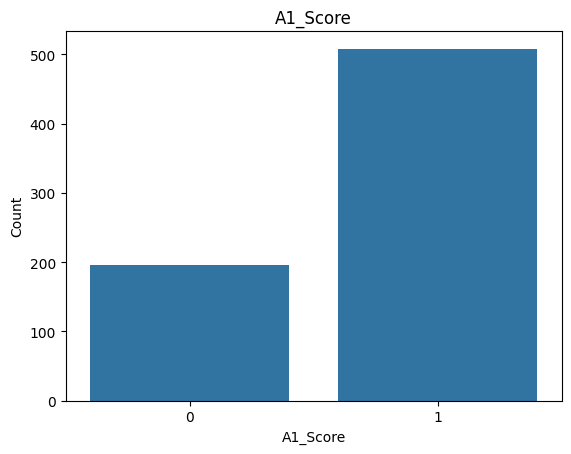

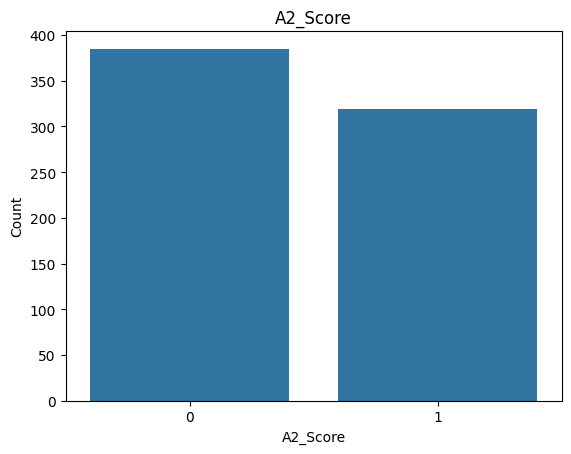

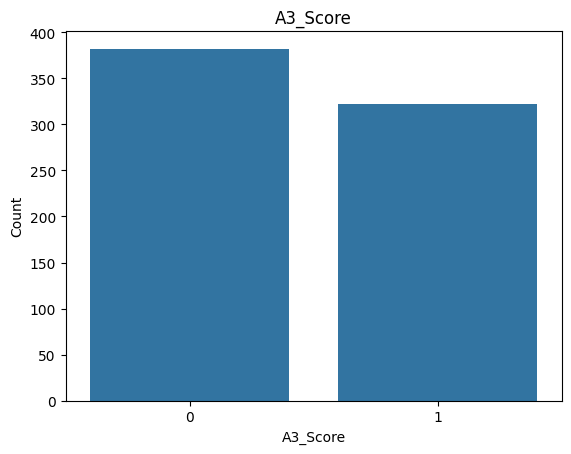

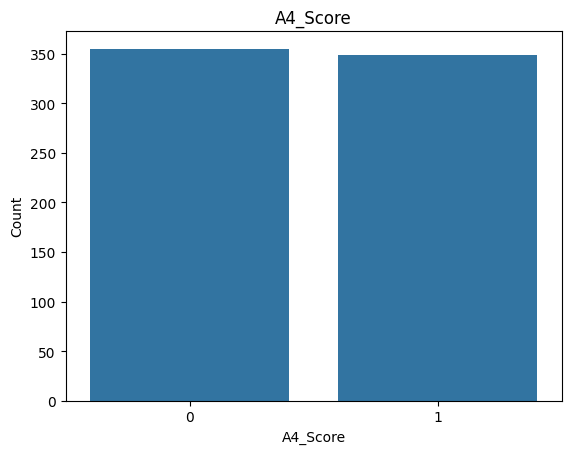

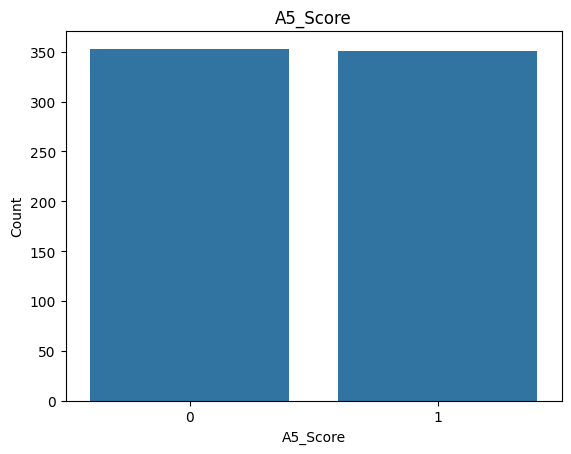

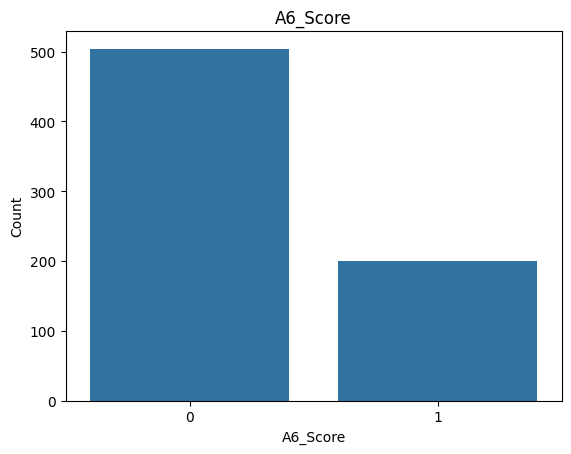

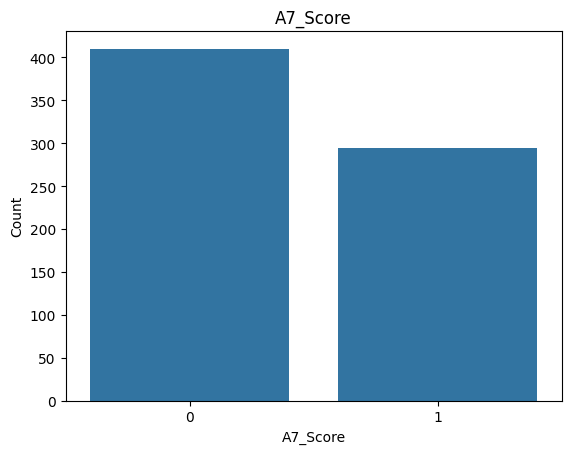

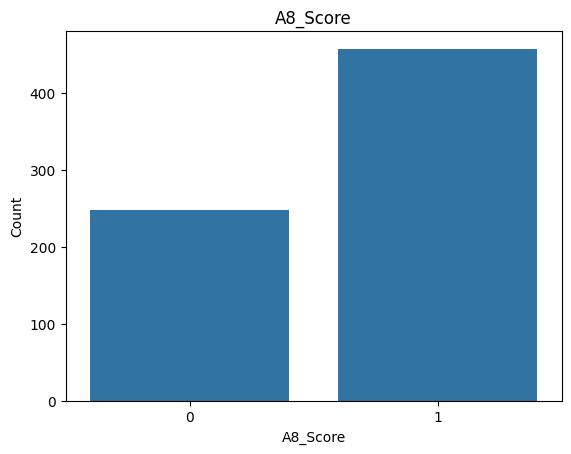

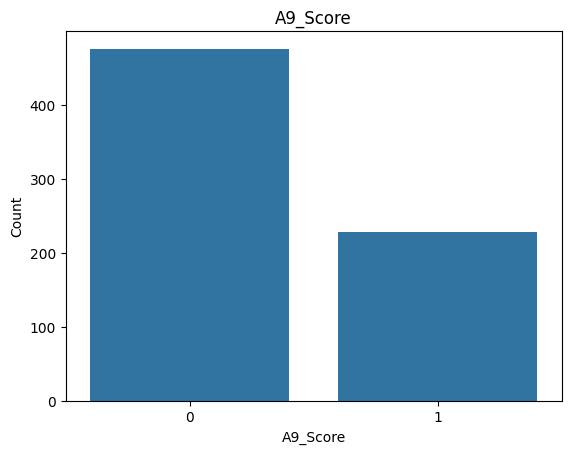

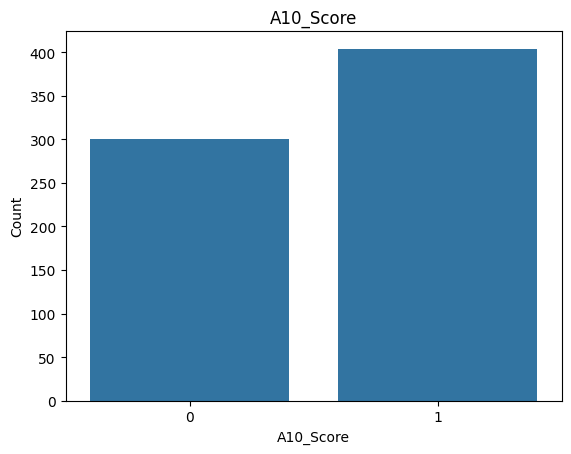

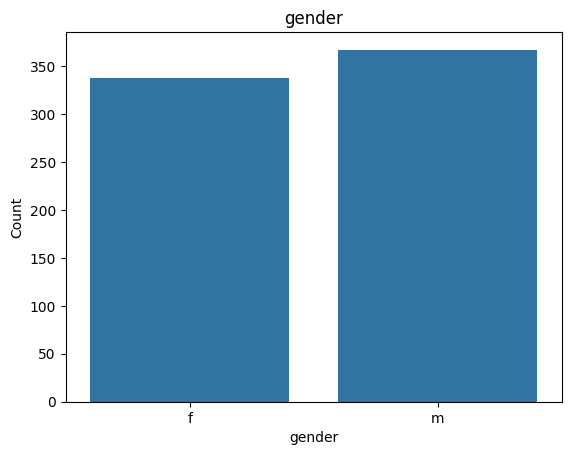

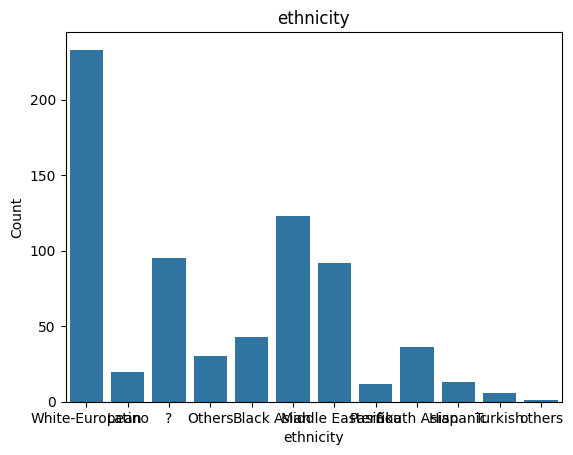

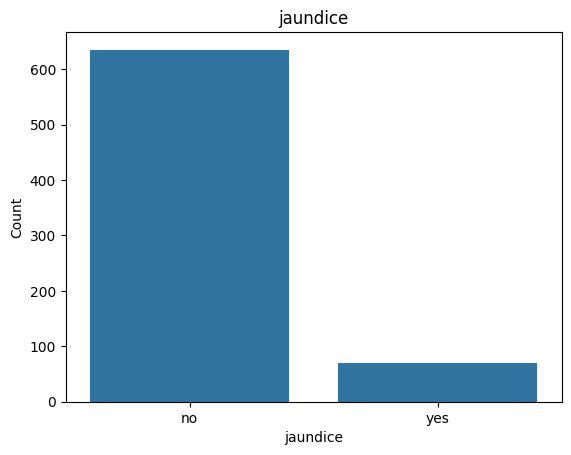

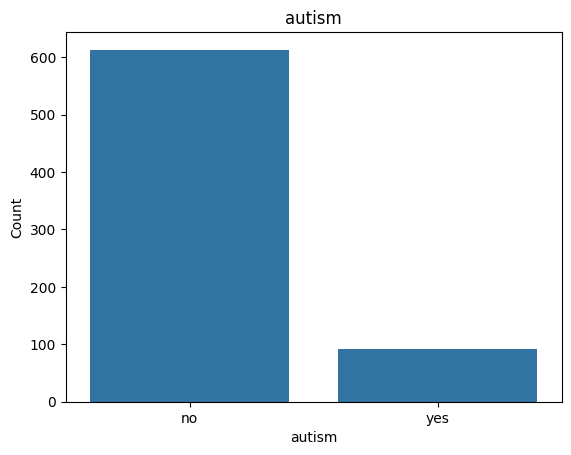

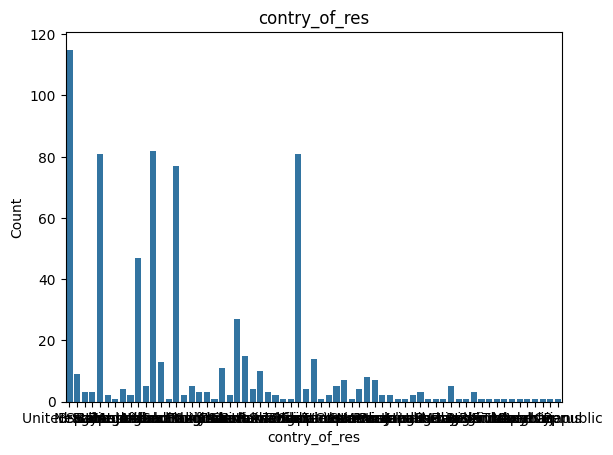

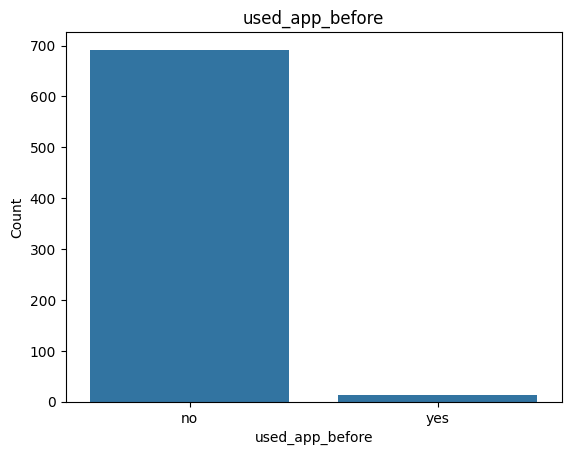

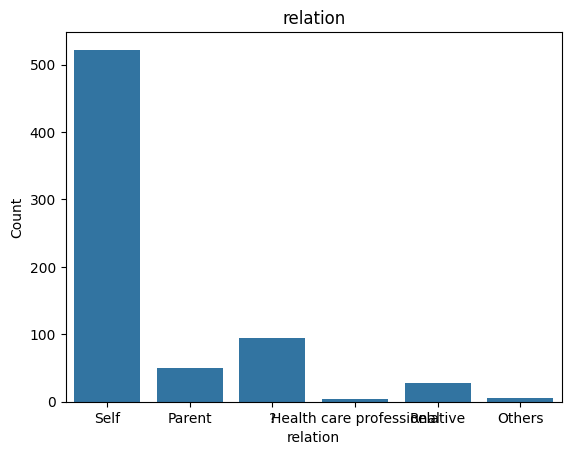

In [291]:
categorical_columns = ['A1_Score','A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
                       'A6_Score','A7_Score', 'A8_Score','A9_Score', 'A10_Score',
                       'gender','ethnicity', 'jaundice', 'autism','contry_of_res',
                       'used_app_before', 'relation']

for col in categorical_columns:
  sns.countplot(x=df[col])
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel ("Count")
  plt.show()
# to check imbalance in data

In [292]:
# handle missing values
df['ethnicity'].unique()

array(['White-European', 'Latino', '?', 'Others', 'Black', 'Asian',
       'Middle Eastern ', 'Pasifika', 'South Asian', 'Hispanic',
       'Turkish', 'others'], dtype=object)

In [293]:
mapping = {"?":"Others",
           "others": "Others"}

df['ethnicity'] = df['ethnicity'].replace(mapping)
# assign "?" as Others
# combine others and Others

In [294]:
df['ethnicity'].unique()

array(['White-European', 'Latino', 'Others', 'Black', 'Asian',
       'Middle Eastern ', 'Pasifika', 'South Asian', 'Hispanic',
       'Turkish'], dtype=object)

In [295]:
# doing same with relation column
df['relation'].unique()

array(['Self', 'Parent', '?', 'Health care professional', 'Relative',
       'Others'], dtype=object)

In [296]:
mapping = {"?":"Others",
           "Relative": "Others",
           "Parent": "Others",
           "Health care professional": "Others"}

df['relation'] = df['relation'].replace(mapping)

In [297]:
df['relation'].unique()

array(['Self', 'Others'], dtype=object)

In [298]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26,f,White-European,no,no,United States,no,6,Self,NO
1,1,1,0,1,0,0,0,1,0,1,24,m,Latino,no,yes,Brazil,no,5,Self,NO
2,1,1,0,1,1,0,1,1,1,1,27,m,Latino,yes,yes,Spain,no,8,Others,YES
3,1,1,0,1,0,0,1,1,0,1,35,f,White-European,no,yes,United States,no,6,Self,NO
4,1,0,0,0,0,0,0,1,0,0,40,f,Others,no,no,Egypt,no,2,Others,NO


ENCODING (categorical to binary)

In [299]:
object_columns = df.select_dtypes(include=['object']).columns
print(object_columns)

# columns with object dtype

Index(['gender', 'ethnicity', 'jaundice', 'autism', 'contry_of_res',
       'used_app_before', 'relation', 'Class/ASD'],
      dtype='object')


In [300]:
from sklearn.preprocessing import LabelEncoder      # nominal data

In [301]:
encoders = {}

for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder

encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'autism': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder(),
 'Class/ASD': LabelEncoder()}

In [302]:
for column, encoder in encoders.items():
  print(f"\n encoding for classes: {column}")
  for idx, label in enumerate(encoder.classes_):
    print(f" {label}-> {idx}")



 encoding for classes: gender
 f-> 0
 m-> 1

 encoding for classes: ethnicity
 Asian-> 0
 Black-> 1
 Hispanic-> 2
 Latino-> 3
 Middle Eastern -> 4
 Others-> 5
 Pasifika-> 6
 South Asian-> 7
 Turkish-> 8
 White-European-> 9

 encoding for classes: jaundice
 no-> 0
 yes-> 1

 encoding for classes: autism
 no-> 0
 yes-> 1

 encoding for classes: contry_of_res
 Afghanistan-> 0
 Angola-> 1
 Argentina-> 2
 Armenia-> 3
 Aruba-> 4
 Australia-> 5
 Austria-> 6
 Azerbaijan-> 7
 Bahamas-> 8
 Bangladesh-> 9
 Belgium-> 10
 Bolivia-> 11
 Brazil-> 12
 Burundi-> 13
 Canada-> 14
 Chile-> 15
 China-> 16
 Costa Rica-> 17
 Cyprus-> 18
 Czech Republic-> 19
 Ecuador-> 20
 Egypt-> 21
 Ethiopia-> 22
 Finland-> 23
 France-> 24
 Germany-> 25
 Iceland-> 26
 India-> 27
 Indonesia-> 28
 Iran-> 29
 Iraq-> 30
 Ireland-> 31
 Italy-> 32
 Japan-> 33
 Jordan-> 34
 Kazakhstan-> 35
 Lebanon-> 36
 Malaysia-> 37
 Mexico-> 38
 Nepal-> 39
 Netherlands-> 40
 New Zealand-> 41
 Nicaragua-> 42
 Niger-> 43
 Oman-> 44
 Pakistan-> 4

In [303]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,autism,contry_of_res,used_app_before,result,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,26,0,9,0,0,62,0,6,1,0
1,1,1,0,1,0,0,0,1,0,1,24,1,3,0,1,12,0,5,1,0
2,1,1,0,1,1,0,1,1,1,1,27,1,3,1,1,54,0,8,0,1
3,1,1,0,1,0,0,1,1,0,1,35,0,9,0,1,62,0,6,1,0
4,1,0,0,0,0,0,0,1,0,0,40,0,5,0,0,21,0,2,0,0


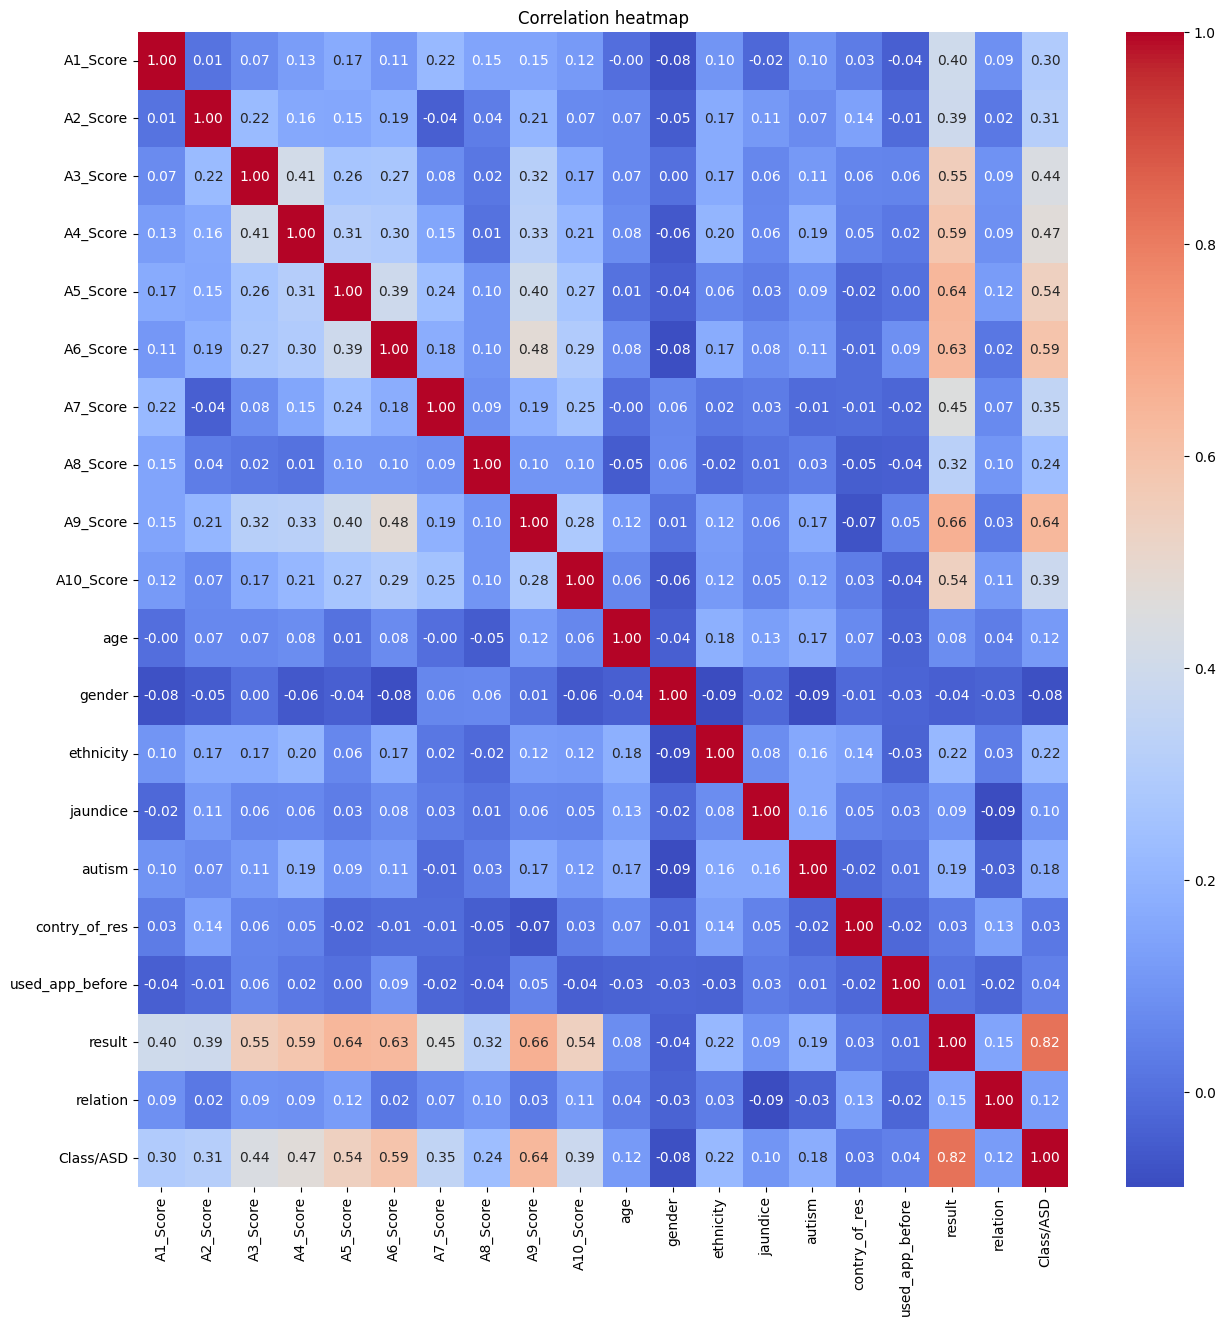

In [304]:
# correlation matrix
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()
#df.corr():Calculates the correlation matrix for all numeric columns in your dataset.
#Tells how strongly each column is related to the others.

In [305]:
# Correlation of each feature with target variable

correlation_with_target = df.corr()['Class/ASD'].sort_values(ascending=False)

print("Correlation with Class/ASD:\n")
print(correlation_with_target)

# Features having very weak correlation
weak_features = correlation_with_target[
    correlation_with_target.abs() < 0.1
]

print("\nFeatures with very weak or no correlation with Class/ASD:\n")
print(weak_features)

Correlation with Class/ASD:

Class/ASD          1.000000
result             0.821445
A9_Score           0.635576
A6_Score           0.592091
A5_Score           0.537004
A4_Score           0.469945
A3_Score           0.441074
A10_Score          0.385917
A7_Score           0.351429
A2_Score           0.311382
A1_Score           0.297628
A8_Score           0.237161
ethnicity          0.219510
autism             0.177415
relation           0.123437
age                0.116475
jaundice           0.102152
used_app_before    0.044038
contry_of_res      0.025055
gender            -0.080378
Name: Class/ASD, dtype: float64

Features with very weak or no correlation with Class/ASD:

used_app_before    0.044038
contry_of_res      0.025055
gender            -0.080378
Name: Class/ASD, dtype: float64


In [306]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
0,515
1,189


In [307]:
X = df.drop(columns=['Class/ASD', 'result'])
y = df['Class/ASD']

In [308]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y, random_state=42, test_size=0.2, stratify=y
)

In [309]:
y_train.value_counts()

,count
Class/ASD,
0,412
1,151


In [310]:
y_test.value_counts()

,count
Class/ASD,
0,103
1,38


SMOTE (for data imbalance)
generate synthetic samples for minority class

In [311]:
smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(
    x_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
Class/ASD
0    412
1    151
Name: count, dtype: int64

After SMOTE
Class/ASD
0    412
1    412
Name: count, dtype: int64


**DECISION TREE**

In [312]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(x_train_smote, y_train_smote)

dt_pred = dt.predict(x_test)

print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



**RANDOM FOREST**

In [313]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train_smote, y_train_smote)

rf_pred = rf.predict(x_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



**XGBOOST**

In [314]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(x_train_smote, y_train_smote)

xgb_pred = xgb.predict(x_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        38

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



**Confusion Matrix Function**

In [315]:
def plot_cm(y_true, y_pred, title):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

**Plot All Matrices**

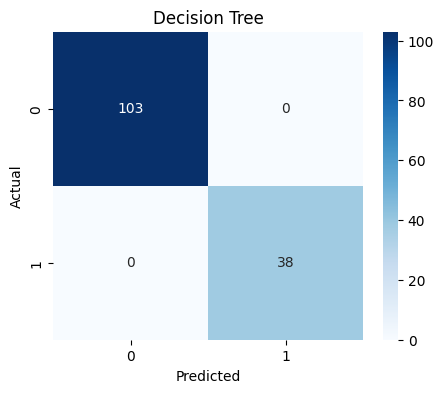

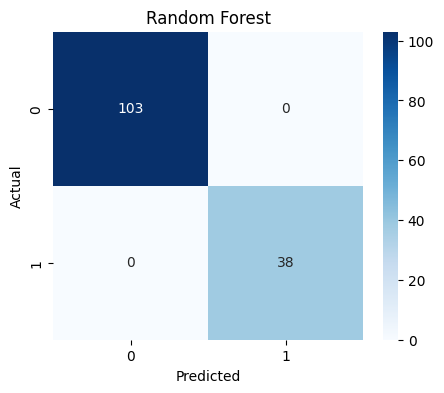

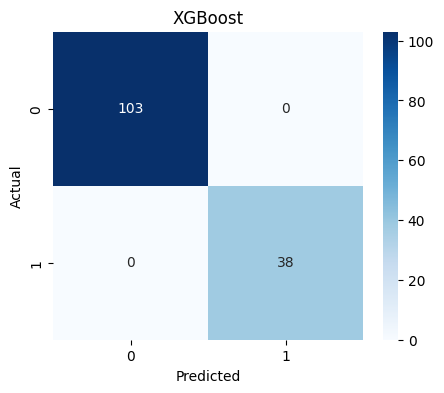

In [316]:
plot_cm(y_test, dt_pred, "Decision Tree")

plot_cm(y_test, rf_pred, "Random Forest")

plot_cm(y_test, xgb_pred, "XGBoost")

**Compare Models**

In [317]:
results = pd.DataFrame({
    'Model':[
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy':[
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0
2,XGBoost,1.0


**Feature Importance (Random Forest)**

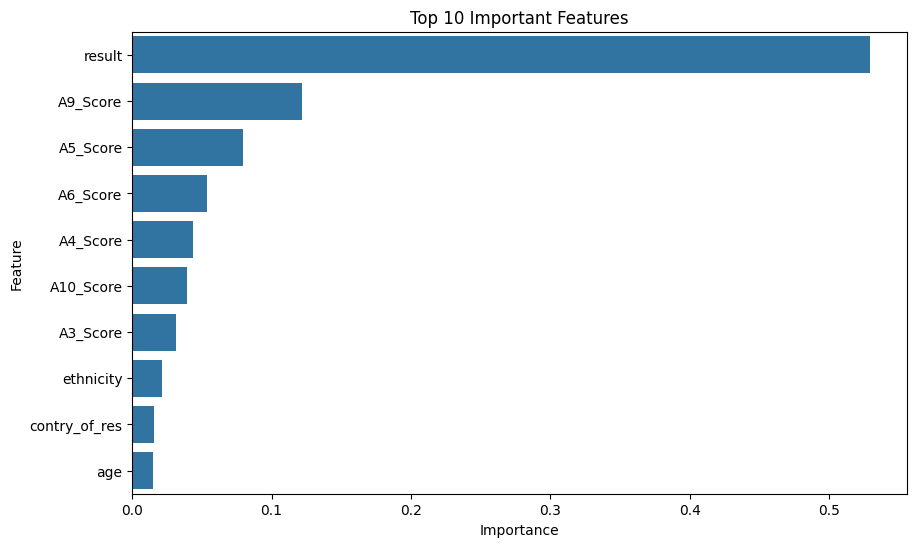

In [318]:
importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [320]:
print(X.shape)
print(y.shape)

(704, 18)
(704,)


In [321]:
print(y_train.value_counts())
print(y_test.value_counts())

Class/ASD
0    412
1    151
Name: count, dtype: int64
Class/ASD
0    103
1     38
Name: count, dtype: int64


In [323]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

[0.96453901 0.96453901 0.95035461 0.9858156  0.93571429]
Mean Accuracy: 0.9601925025329281
Std: 0.016675099414751454


In [324]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    rf,
    X,
    y,
    cv=5,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1'
    ]
)

print("Accuracy :", scores['test_accuracy'].mean())
print("Precision:", scores['test_precision'].mean())
print("Recall   :", scores['test_recall'].mean())
print("F1 Score :", scores['test_f1'].mean())

Accuracy : 0.9601925025329281
Precision: 0.9602886002886002
Recall   : 0.8887624466571836
F1 Score : 0.9228214902148917
